In [1]:
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression, Lasso, Ridge

from sklearn.metrics import mean_squared_error

# MLOps Zoomcamp: Taxi Ride Duration Prediction (PART 1)
---
## PART 1: Training and In-Sample Inference (Baseline Model)
In this initial phase, the data is loaded, filtered for outliers, and vectorized. We establish a baseline using a simple Linear Regression model evaluated purely on the training set.

In [2]:
# Load January 2021 Green Taxi Dataset
df = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-01.parquet')
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.5,0.5,0.5,0.00,0.0,None,0.3,6.80,2.0,1.0,0.00
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.0,0.5,0.5,2.81,0.0,None,0.3,16.86,1.0,1.0,2.75
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.0,0.5,0.5,1.00,0.0,None,0.3,8.30,1.0,1.0,0.00
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.0,0.5,0.5,0.00,0.0,None,0.3,9.30,2.0,1.0,0.00
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.0,0.0,-0.5,0.00,0.0,None,-0.3,-52.80,3.0,1.0,0.00


### Target Engineering
The target variable `duration` is computed in minutes by taking the difference between the drop-off and pickup datetimes.

In [3]:
df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

df.duration.head()

0    3.933333
1    8.750000
2    5.966667
3    7.083333
4    0.066667
Name: duration, dtype: float64

### Outlier Removal
The raw duration contains extreme values (trips lasting 0 minutes or up to 24 hours). To focus on standard business operations, we filter the dataset to keep only trips between 1 and 60 minutes, which retains roughly **96.6%** of the data.

In [4]:
df.duration.describe()

count    76518.000000
mean        19.927896
std         59.338594
min          0.000000
25%          8.000000
50%         13.883333
75%         23.000000
max       1439.600000
Name: duration, dtype: float64

In [5]:
((df.duration >= 1) & (df.duration <= 60)).mean()

0.9658903787344154

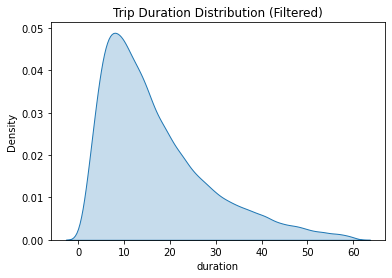

In [6]:
# Filter dataset
df = df[((df.duration >= 1) & (df.duration <= 60))]

# Visualize target distribution
sns.kdeplot(df.duration, fill=True)
plt.title('Trip Duration Distribution (Filtered)')
plt.show()

### Categorical Encoding & Vectorization
The locations IDs (`PULocationID`, `DOLocationID`) are cast from integers to strings to treat them as true categorical entities. We map our mixed features into dictionaries and use `DictVectorizer` to execute One-Hot Encoding.

In [7]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

train_dicts = df[categorical + numerical].to_dict(orient='records')
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

### Baseline In-Sample Training
A standard `LinearRegression` model is fitted on the training feature matrix `X_train`. Evaluating the predictions against `y_train` yields an in-sample Root Mean Squared Error (RMSE) of approximately 9.77 minutes.

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_predict = lr.predict(X_train)

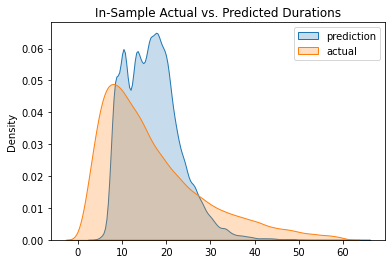

In [9]:
# Compare actual vs prediction distributions gracefully
sns.kdeplot(y_predict, label='prediction', fill=True)
sns.kdeplot(y_train, label='actual', fill=True)
plt.title('In-Sample Actual vs. Predicted Durations')
plt.legend()
plt.show()

In [13]:
mean_squared_error(y_train, y_predict, squared=False)

9.775464278878395

## PART 2: Pipeline Refactoring and Out-of-Sample Validation
To eliminate redundancy and ensure consistency, the complete preprocessing workflow is consolidated into a single function: `read_dataframe()`.

In [14]:
def read_dataframe(filename):
    df = pd.read_parquet(filename)
    
    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)
    
    df = df[((df.duration >= 1) & (df.duration <= 60))]
    
    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

Using the centralized function, distinct DataFrames are initialized for training (`df_train` using January data) and validation (`df_val` using February data).

In [15]:
df_train = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-01.parquet')
df_val = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-02.parquet')

>**MLOps Best Practice:** The `DictVectorizer` is fitted exclusively on the training records using `.fit_transform()`. Crucially, the validation records are processed using `.transform()` only to prevent data leakage.

In [16]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

### Validation Performance Assessment

In [20]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_predict = lr.predict(X_val)
rmse_val = mean_squared_error(y_val, y_predict, squared=False)
print(f"Validation Base RMSE: {rmse_val} minutes")

Validation Base RMSE: 10.473871054242926 minutes


### Regularization Hyperparameter Tuning
Exploring alternative linear constraints (`Lasso` and `Ridge`) to try and beat the validation baseline score.

In [21]:
for alpha in [0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]:
    model = Lasso(alpha=alpha)
    model.fit(X_train, y_train)
    y_predict = model.predict(X_val)
    error = mean_squared_error(y_val, y_predict, squared=False)
    print(f"Alpha = {alpha:<6} | Validation RMSE = {error:.2f}")

Alpha = 0.05   | Validation RMSE = 11.44
Alpha = 0.01   | Validation RMSE = 10.81
Alpha = 0.005  | Validation RMSE = 10.64
Alpha = 0.001  | Validation RMSE = 10.48
Alpha = 0.0005 | Validation RMSE = 10.47
Alpha = 0.0001 | Validation RMSE = 10.47


In [22]:
for alpha in [0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    y_predict = model.predict(X_val)
    error = mean_squared_error(y_val, y_predict, squared=False)
    print(f"Alpha = {alpha:<6} | Validation RMSE = {error:.2f}")

Alpha = 0.05   | Validation RMSE = 10.86
Alpha = 0.01   | Validation RMSE = 10.86
Alpha = 0.005  | Validation RMSE = 10.86
Alpha = 0.001  | Validation RMSE = 10.86
Alpha = 0.0005 | Validation RMSE = 10.86
Alpha = 0.0001 | Validation RMSE = 10.86


## PART 3: Feature Engineering (Feature Interactions) and Model Artifact Serialization
To capture complex spatial route dynamics, we engineer a new categorical feature: `PU_DO`. By concatenating the pickup location ID and drop-off location ID with an underscore separator, we convert isolated spatial points into explicit directional travel corridors (`'130_205'`).

In [23]:
# Re-load clean datasets to avoid feature mismatch
df_train = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-01.parquet')
df_val = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-02.parquet')

# Create Interaction Feature
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

df_val['PU_DO'].head()

0    130_205
1    152_244
2     152_48
3    152_241
4      75_42
Name: PU_DO, dtype: object

In [24]:
categorical = ['PU_DO'] 
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

y_train = df_train['duration'].values
y_val = df_val['duration'].values

### Training Linear Regression on Unified Locations

In [26]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_predict = lr.predict(X_val)
rmse_interaction = mean_squared_error(y_val, y_predict, squared=False)
print(f"Validation Interaction Space RMSE: {rmse_interaction} minutes")

Validation Interaction Space RMSE: 7.4793657829373155 minutes


### Regularization Tuning on Unified Locations

In [27]:
for alpha in [0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]:
    model = Lasso(alpha=alpha)
    model.fit(X_train, y_train)
    y_predict = model.predict(X_val)
    error = mean_squared_error(y_val, y_predict, squared=False)
    print(f"Alpha = {alpha:<6} | Validation RMSE = {error:.2f}")

Alpha = 0.05   | Validation RMSE = 11.91
Alpha = 0.01   | Validation RMSE = 11.17
Alpha = 0.005  | Validation RMSE = 10.70
Alpha = 0.001  | Validation RMSE = 9.23
Alpha = 0.0005 | Validation RMSE = 8.55
Alpha = 0.0001 | Validation RMSE = 7.62


In [28]:
for alpha in [0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    y_predict = model.predict(X_val)
    error = mean_squared_error(y_val, y_predict, squared=False)
    print(f"Alpha = {alpha:<6} | Validation RMSE = {error:.2f}")

Alpha = 0.05   | Validation RMSE = 11.34
Alpha = 0.01   | Validation RMSE = 11.34
Alpha = 0.005  | Validation RMSE = 11.34
Alpha = 0.001  | Validation RMSE = 11.34
Alpha = 0.0005 | Validation RMSE = 11.34
Alpha = 0.0001 | Validation RMSE = 11.34


### Model Artifact Serialization
Saving the fitted vectorizer and best performing model parameters inside a production binary file.

In [29]:
import os
os.makedirs('models', exist_ok=True)

with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)